# Correlation realized as a GEMM (Generalized Matrix Multiply) Operation

The following code demonstrates how to perform the correlation of the $2\times2$ weight matrix $\mathbf{W}$


\begin{equation}
\mathbf{W}=
\begin{bmatrix}
w_{0,0} & w_{0,1}\\
w_{1,0} & w_{1,1}
\end{bmatrix}
\end{equation}

with a $4 \times 4$ matrix $\mathbf{X}$
\begin{equation}
\mathbf{X}=
\begin{bmatrix}
x_{0,0} & x_{0,1} & x_{0,2} & x_{0,3} \\
x_{1,0} & x_{1,1} & x_{1,2} & x_{1,3} \\
x_{2,0} & x_{2,1} & x_{2,2} & x_{2,3} \\
x_{3,0} & x_{3,1} & x_{3,2} & x_{3,3}
\end{bmatrix}
\end{equation}

to produce the $2 \times 2$ output matrix $\mathbf{Y}$
\begin{equation}
\mathbf{Y}=
\begin{bmatrix}
y_{0,0} & y_{0,1}\\
y_{1,0} & y_{1,1}
\end{bmatrix}
\end{equation}

using the GEMM (General Matrix Multiply) approach.

First the input filter kernel $\mathbf{w}$ is transformed in to a $1 \times 4$ vector
$\hat{\mathbf{w}}$ as follows

\begin{equation}
\hat{\mathbf{w}}=
\begin{bmatrix}
w_{0,0} & w_{0,1} & w_{1,0} & w_{1,1}\\
\end{bmatrix}
\end{equation}
The data matrix $\mathbf{X}$ is transformed in to the $4 \times 9$ matrix $\hat{\mathbf{X}}$

\begin{equation}
\hat{\mathbf{X}}=
\begin{bmatrix}
x_{0,0} & x_{0,1} & x_{0,2} & x_{1,0} & x_{1,1} & x_{1,2} & x_{2,0} & x_{2,1} & x_{2,2}\\
x_{0,1} & x_{0,2} & x_{0,3} & x_{1,1} & x_{1,2} & x_{1,3} & x_{2,1} & x_{2,2} & x_{2,3}\\
x_{1,0} & x_{1,1} & x_{1,2} & x_{2,0} & x_{2,1} & x_{2,2} & x_{3,0} & x_{3,1} & x_{3,2}\\
x_{1,1} & x_{1,2} & x_{1,3} & x_{2,1} & x_{2,2} & x_{2,3} & x_{3,1} & x_{3,2} & x_{3,3}
\end{bmatrix}
\end{equation}

The data permutation that maps $\mathbf{X}$ to $\hat{\mathbf{X}}$ is frequently called 'Im2Col'.


The following matrix product is then computed
\begin{equation}
\hat{\mathbf{Y}} = \hat{\mathbf{W}} \hat{\mathbf{X}}
\end{equation}

This is shown explicitly in the following equation

\begin{equation}
\underbrace{
\begin{bmatrix}
y_{0,0} & y_{0,1} & y_{1,0} & y_{1,1}\\
\end{bmatrix}}_{\hat{\mathbf{Y}}}=
\underbrace{
\begin{bmatrix}
w_{0,0} & w_{0,1} & w_{1,0} & w_{1,1}\\
\end{bmatrix}}_{\hat{\mathbf{W}}}\times
\underbrace{
\begin{bmatrix}
x_{0,0} & x_{0,1} & x_{0,2} & x_{0,3} & x_{0,4} & x_{0,5} & x_{0,6} & x_{0,7} & x_{0,8}\\
x_{1,0} & x_{1,1} & x_{1,2} & x_{1,3} & x_{1,4} & x_{1,5} & x_{1,6} & x_{1,7} & x_{1,8}\\
x_{2,0} & x_{2,1} & x_{2,2} & x_{2,3} & x_{2,4} & x_{2,5} & x_{2,6} & x_{2,7} & x_{2,8}\\
x_{3,0} & x_{3,1} & x_{3,2} & x_{3,3} & x_{3,4} & x_{3,5} & x_{3,6} & x_{3,7} & x_{3,8}
\end{bmatrix}}_{\hat{\mathbf{X}}}
\end{equation}

The $1 \times 4$ output vector $\hat{\mathbf{Y}}$ is reshaped in to the desired $2 \times 2$ matrix
$\mathbf{Y}$ to produce the final result

\begin{equation}
\mathbf{Y}=
\begin{bmatrix}
y_{0,0} & y_{0,1}\\
y_{1,0} & y_{1,1}
\end{bmatrix}
\end{equation}

           
            

In [1]:
import numpy as np
from scipy import signal
from scipy import misc
import seaborn as sns
import matplotlib.pylab as plt

/tmp/ipykernel_423/881828855.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


In [2]:
def Im2Col(a, x_nrows, x_ncols, filter_nrows, filter_ncols,
                    im2col_ofm_nrows, im2col_ofm_ncols, filter_size):


    # allocate the Im2Col() output matrix
    z = np.zeros((filter_size, im2col_ofm_nrows*im2col_ofm_ncols))

    col = 0

    for m in range(0, (x_nrows-filter_nrows+1)):
        for n in range(0, (x_ncols-filter_ncols+1)):
            row_offset = 0
            k = 0
            for p in range(0, filter_ncols):
                for q in range(0, filter_nrows):
                    z[row_offset + k, col] = a[m+p, n+q]
                    k = k + 1
            col = col + 1
    return z

In [3]:
# first simple test

# constants

top_pad = 0
left_pad = 0
x_nrows = 4
x_ncols = 4
filter_nrows = 2
filter_ncols = 2

im2col_ofm_nrows = (x_nrows - filter_nrows + 2*top_pad) + 1
im2col_ofm_ncols = (x_ncols - filter_ncols + 2*left_pad) + 1
filter_size = filter_nrows*filter_ncols

# define a simple data matrix
x = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]])
# define a filter kernel
w = np.array([[1, 2], [3, 4]])

print('Input test matrix:')
print(x)

# Apply the im2col transformation on the test matrix x
y = Im2Col(x, x_nrows, x_ncols, filter_nrows, filter_ncols,
          im2col_ofm_nrows, im2col_ofm_ncols, filter_size)
print('\n' + 'Im2Col(x)')
print(y)

# scipy will be used to generate reference data for Conv2D(). This 'golden'
# reference will be used to compare with Conv2D() performusing the GEMM approach.

# First generate the golden reference
# Convolve (really correlate) the network with the layer filter(s) using scipy


# ofm = Output Feature Map
ofm_nrows = (x_nrows - filter_nrows + 2*top_pad) + 1
ofm_ncols = (x_ncols - filter_ncols + 2*left_pad) + 1


# flatten the filter_nrows x filter_ncols filter kernel in to
# a 1 x (filter_nrwos x filter_ncols) vector

w_flat = np.reshape(w, (1, filter_nrows*filter_ncols))

conv_using_gemm_tmp = np.dot(w_flat, y )
print("\nConv Using Gemm Flat")
print(conv_using_gemm_tmp)

conv_using_gemm = np.reshape(conv_using_gemm_tmp, (ofm_nrows, ofm_ncols))
conv = signal.correlate2d(x, w, mode='valid')
print('\nconv performed using scipy')
print(conv)

print('\n' + 'conv using GEMM')
print(conv_using_gemm)

# take the difference of the matrics to confirm that there is no difference between then

diff = conv - conv_using_gemm
sum_diff = sum(sum(diff))         # sum_diff should be 0

print('\nsum_diff = ', sum_diff)

Input test matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Im2Col(x)
[[ 1.  2.  3.  5.  6.  7.  9. 10. 11.]
 [ 2.  3.  4.  6.  7.  8. 10. 11. 12.]
 [ 5.  6.  7.  9. 10. 11. 13. 14. 15.]
 [ 6.  7.  8. 10. 11. 12. 14. 15. 16.]]

Conv Using Gemm Flat
[[ 44.  54.  64.  84.  94. 104. 124. 134. 144.]]

conv performed using scipy
[[ 44  54  64]
 [ 84  94 104]
 [124 134 144]]

conv using GEMM
[[ 44.  54.  64.]
 [ 84.  94. 104.]
 [124. 134. 144.]]

sum_diff =  0.0


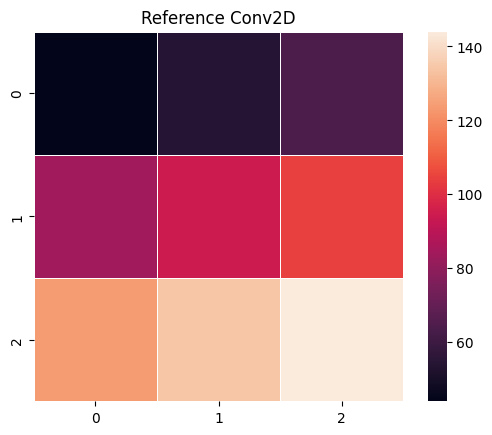

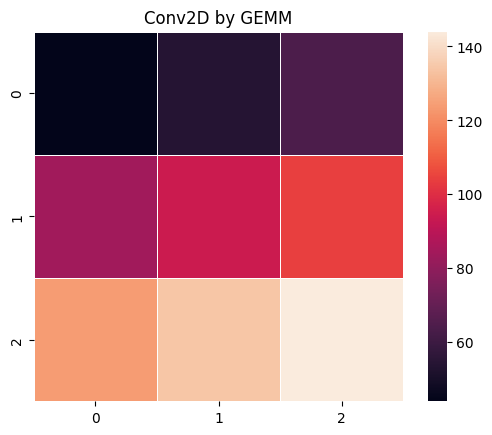

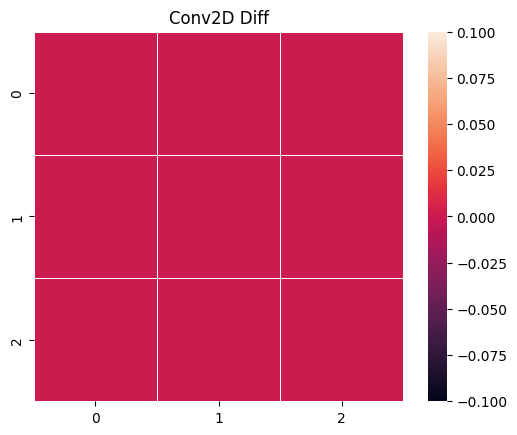

In [4]:
# for fun plot the data sets as heatmaps

ax = sns.heatmap(conv, square='true', linewidth=0.5)
plt.title('Reference Conv2D')
plt.show()

ax = sns.heatmap(conv_using_gemm, square='true', linewidth=0.5)
plt.title('Conv2D by GEMM')
plt.show()

ax = sns.heatmap(diff, square='true', linewidth=0.5)
plt.title('Conv2D Diff')
plt.show()

In [5]:
# here is another test using a larger data matrix and larger filter kernel

top_pad = 0
left_pad = 0
x_nrows = 28
x_ncols = 28
filter_nrows = 3
filter_ncols = 3
# ofm = Output Feature Map
im2col_ofm_nrows = (x_nrows - filter_nrows + 2*top_pad) + 1
im2col_ofm_ncols = (x_ncols - filter_ncols + 2*left_pad) + 1
filter_size = filter_nrows*filter_ncols

print('im2col_ofm_nrows =', im2col_ofm_nrows)
print('im2col_ofm_ncols =', im2col_ofm_ncols)
print('filter_size = ', filter_size)

# define a simple data matrix
x = np.random.rand(x_nrows, x_ncols)
# define a filter kernel
w = np.random.rand(filter_nrows, filter_ncols)

# Apply the im2col transformation on the test matrix x
y = Im2Col(x, x_nrows, x_ncols, filter_nrows, filter_ncols,
          im2col_ofm_nrows, im2col_ofm_ncols, filter_size)

# scipy will be used to generate reference data for Conv2D(). This 'golden'
# reference will be used to compare with Conv2D() performusing the GEMM approach.

# First generate the golden reference
# Convolve (really correlate) the network with the layer filter(s) using scipy


# ofm = Output Feature Map
ofm_nrows = (x_nrows - filter_nrows + 2*top_pad) + 1
ofm_ncols = (x_ncols - filter_ncols + 2*left_pad) + 1


# flatten the filter_nrows x filter_ncols filter kernel in to
# a 1 x (filter_nrwos x filter_ncols) vector

w_flat = np.reshape(w, (1, filter_nrows*filter_ncols))

conv_using_gemm_tmp = np.dot(w_flat, y )
conv_using_gemm = np.reshape(conv_using_gemm_tmp, (ofm_nrows, ofm_ncols))
conv = signal.correlate2d(x, w, mode='valid')

# take the difference of the matrics to confirm that there is no difference between then

diff = conv - conv_using_gemm
sum_diff = sum(sum(diff))         # sum_diff should be 0

print('\nsum_diff = ', sum_diff)

im2col_ofm_nrows = 26
im2col_ofm_ncols = 26
filter_size =  9

sum_diff =  7.771561172376096e-15


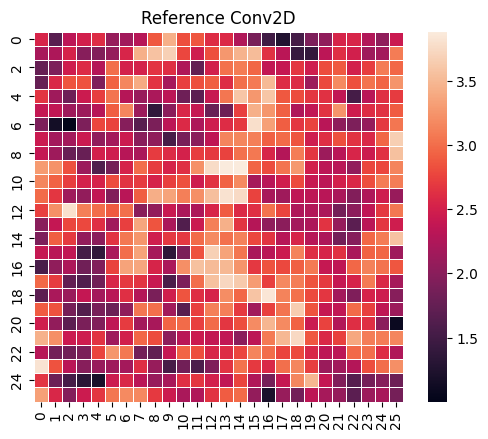

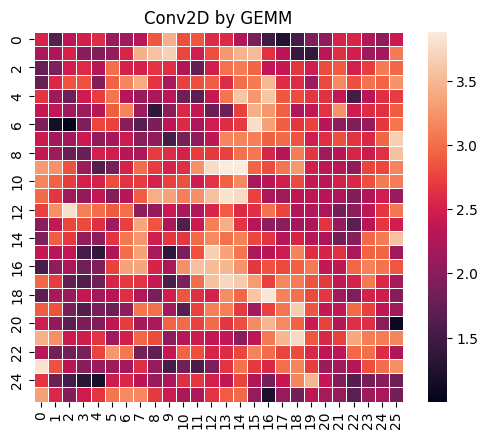

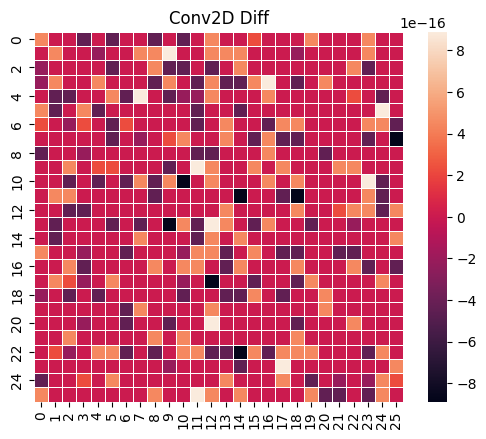

In [6]:
# for fun plot the data sets as heatmaps

ax = sns.heatmap(conv, square='true', linewidth=0.5)
plt.title('Reference Conv2D')
plt.show()

ax = sns.heatmap(conv_using_gemm, square='true', linewidth=0.5)
plt.title('Conv2D by GEMM')
plt.show()

ax = sns.heatmap(diff, square='true', linewidth=0.5)
plt.title('Conv2D Diff')
plt.show()
